In [2]:
# =========================================================
# 1. IMPORTS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)

In [3]:
# =========================================================
# 2. LOADED The CLEANED MASTER DATASET
# =========================================================

DATA_PATH = Path("multilingual_ticket_master_cleaned.csv")

print("Dataset exists:", DATA_PATH.exists())
print("Path:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

Dataset exists: True
Path: multilingual_ticket_master_cleaned.csv

Dataset loaded successfully.
Shape: (44278, 21)


/tmp/ipykernel_195/2734466954.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [5]:
# =========================================================
# 3. BASIC DATASET OVERVIEW
# =========================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

DATASET OVERVIEW

Shape:
(44278, 21)

Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'business_type', 'version', 'source_dataset', 'source_count', 'duplicate_record_count', 'label_conflict', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Data types:
subject                    object
body                       object
answer                     object
type                       object
queue                      object
priority                   object
language                   object
business_type              object
version                   float64
source_dataset             object
source_count                int64
duplicate_record_count      int64
label_conflict               bool
tag_1                      object
tag_2                      object
tag_3                      object
tag_4                      object
tag_5                      object
tag_6                      object
tag_7                      object
tag_8      

,subject,body,answer,type,queue,priority,language,business_type,version,source_dataset,source_count,duplicate_record_count,label_conflict,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Problema crítico del servidor requiere atención inmediata,Es necesaria una investigación inmediata sobre la interrupción en el servicio de gestión de AWS que está impactando funciones comerciales esenciales.,Estamos investigando urgentemente el problema con el servicio de gestión de AWS. Proporcionaremos actualizaciones sobre nuestro progreso.,Incident,Technical Support,high,es,IT Services,NaN,multi-lang3-4k,1,1,False,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice, ich hoffe, diese E-Mail erreicht Sie wohl. Ich schreibe, um mich nach der Verfügbarkeit und den Lieferoptionen für da...","Sehr geehrter <name>, vielen Dank, dass Sie uns kontaktiert haben. Das Dell XPS 13 9310 Ultrabook ist derzeit verfügbar. Die geschätzte Lieferzeit...",Request,Customer Service,low,de,Tech Online Store,NaN,multi-lang3-4k,1,1,False,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>, Estou escrevendo para trazer à sua atenção um problema recorrente com o recurso de autocompletação de código no...","Prezado <name>, Obrigado por entrar em contato e nos informar sobre o problema com o recurso de autocompletação de código no IntelliJ IDEA 2024.1....",Incident,Technical Support,high,pt,IT Services,NaN,multi-lang3-4k,1,1,False,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, I am reaching out regarding a high-priority ticket related to our AWS Management Service. We are experiencing signi...","Dear <name>, Thank you for reaching out regarding your AWS Management Service issues. I understand the urgency and the impact on your operational ...",Request,IT Support,high,en,IT Services,NaN,multi-lang3-4k,1,1,False,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN
4,Problème d'affichage de MacBook Air,"Cher équipe de support du magasin en ligne Tech, Je vous écris pour attirer votre attention sur un problème que j'ai rencontré avec mon MacBook Ai...","Cher <name>, Merci de nous avoir contactés concernant le problème avec l'affichage de votre MacBook Air M1. Nous sommes désolés d'apprendre le pro...",Incident,Product Support,low,fr,Tech Online Store,NaN,multi-lang3-4k,1,1,False,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN


In [7]:
# =========================================================4. BASIC INFO # =========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44278 entries, 0 to 44277
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   subject                 39689 non-null  object 
 1   body                    44275 non-null  object 
 2   answer                  44269 non-null  object 
 3   type                    44278 non-null  object 
 4   queue                   44278 non-null  object 
 5   priority                44278 non-null  object 
 6   language                44278 non-null  object 
 7   business_type           4000 non-null   object 
 8   version                 28586 non-null  float64
 9   source_dataset          44278 non-null  object 
 10  source_count            44278 non-null  int64  
 11  duplicate_record_count  44278 non-null  int64  
 12  label_conflict          44278 non-null  bool   
 13  tag_1                   44278 non-null  object 
 14  tag_2                   44219 non-null

In [8]:
# ========================================================= 5. MISSING VALUE ANALYSIS # =========================================================

missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

display(missing_report)

,missing_count,missing_percent
tag_8,41553,93.845702
business_type,40278,90.966168
tag_7,37404,84.475360
tag_6,29806,67.315597
tag_5,16754,37.838204
version,15692,35.439722
subject,4589,10.364063
tag_4,3515,7.938480
tag_3,196,0.442658
tag_2,59,0.133249


In [9]:
# ========================================================= 6. DUPLICATE ANALYSIS # =========================================================#

print("Exact duplicate rows:")
print(df.duplicated().sum())

if "ticket_text" in df.columns:
    print("\nDuplicate ticket_text values:")
    print(df.duplicated(subset=["ticket_text"]).sum())

Exact duplicate rows:
0


In [10]:
# ========================================================= 7. UNIQUE VALUE COUNTS # =========================================================#

for col in df.columns:

    if df[col].dtype == "object":

        unique_count = df[col].nunique(dropna=False)

        print(f"{col}: {unique_count:,} unique values")

subject: 36,969 unique values
body: 44,181 unique values
answer: 44,079 unique values
type: 4 unique values
queue: 10 unique values
priority: 3 unique values
language: 5 unique values
business_type: 10 unique values
source_dataset: 4 unique values
tag_1: 251 unique values
tag_2: 406 unique values
tag_3: 659 unique values
tag_4: 928 unique values
tag_5: 1,039 unique values
tag_6: 1,002 unique values
tag_7: 821 unique values
tag_8: 562 unique values


In [11]:
# ========================================================= 8. TARGET VARIABLE: QUEUE DISTRIBUTION # =========================================================#

if "queue" in df.columns:

    queue_counts = df["queue"].value_counts()

    print("Queue counts:")
    display(queue_counts)

    print("\nQueue percentages:")
    display(
        (queue_counts / len(df) * 100)
        .round(2)
    )

Queue counts:


queue
Technical Support                  13095
Product Support                     8113
Customer Service                    6741
IT Support                          5237
Billing and Payments                4368
Returns and Exchanges               2204
Service Outages and Maintenance     1710
Sales and Pre-Sales                 1393
Human Resources                      802
General Inquiry                      615
Name: count, dtype: int64


Queue percentages:


queue
Technical Support                  29.57
Product Support                    18.32
Customer Service                   15.22
IT Support                         11.83
Billing and Payments                9.86
Returns and Exchanges               4.98
Service Outages and Maintenance     3.86
Sales and Pre-Sales                 3.15
Human Resources                     1.81
General Inquiry                     1.39
Name: count, dtype: float64

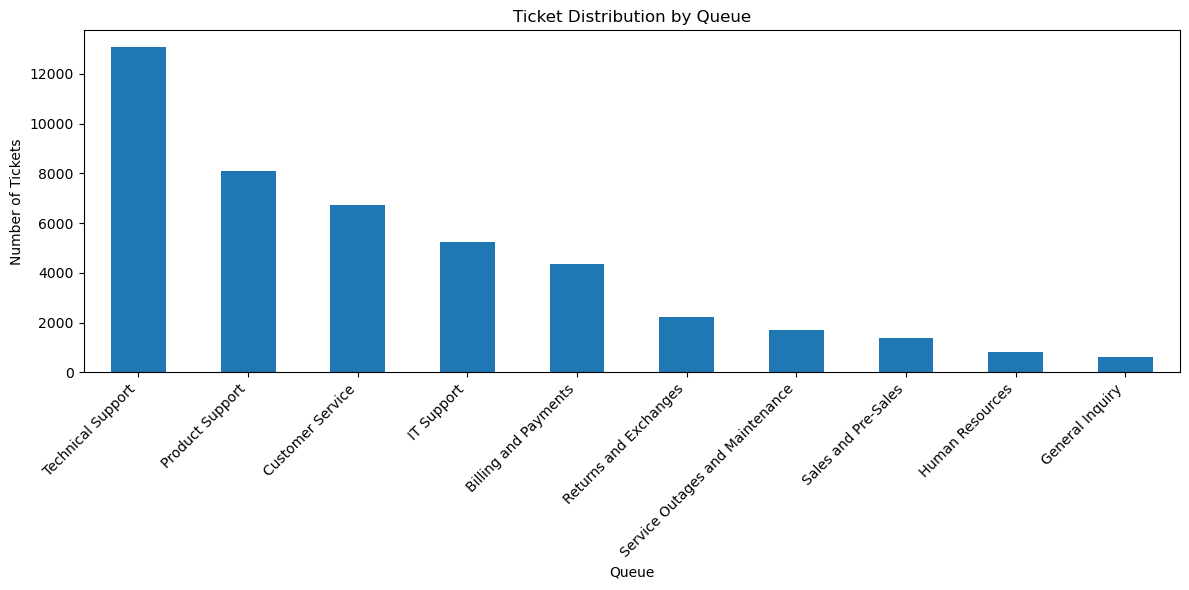

In [12]:
# ========================================================= 9. QUEUE DISTRIBUTION PLOT # =========================================================#

if "queue" in df.columns:

    queue_counts = df["queue"].value_counts()

    plt.figure(figsize=(12, 6))
    queue_counts.plot(kind="bar")

    plt.title("Ticket Distribution by Queue")
    plt.xlabel("Queue")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [13]:
# ========================================================= 10. PRIORITY DISTRIBUTION =========================================================#

if "priority" in df.columns:

    priority_counts = df["priority"].value_counts(dropna=False)

    print("Priority counts:")
    display(priority_counts)

    print("\nPriority percentages:")
    display(
        (priority_counts / len(df) * 100)
        .round(2)
    )

Priority counts:


priority
medium    17961
high      17355
low        8962
Name: count, dtype: int64


Priority percentages:


priority
medium    40.56
high      39.20
low       20.24
Name: count, dtype: float64

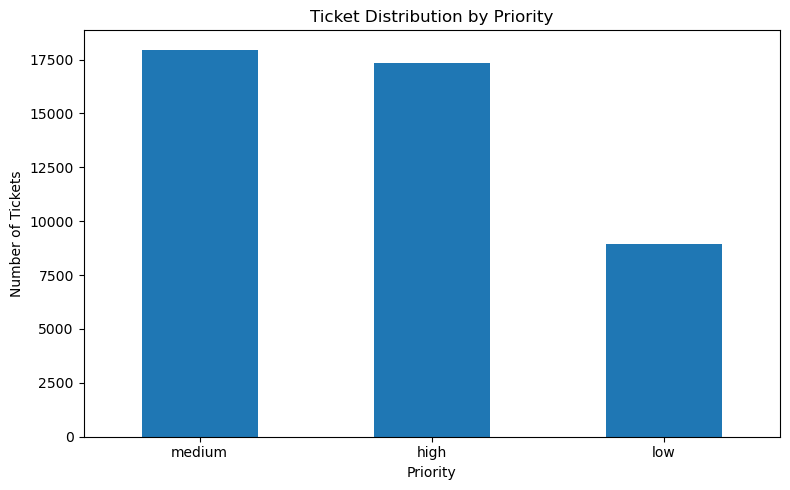

In [14]:
# ========================================================= PRIORITY DISTRIBUTION PLOT =========================================================#

if "priority" in df.columns:

    df["priority"].value_counts().plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Ticket Distribution by Priority")
    plt.xlabel("Priority")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [15]:
# ========================================================= 12. TICKET TYPE DISTRIBUTION=========================================================#

if "type" in df.columns:

    type_counts = df["type"].value_counts(dropna=False)

    print("Ticket type counts:")
    display(type_counts)

    print("\nTicket type percentages:")
    display(
        (type_counts / len(df) * 100)
        .round(2)
    )

Ticket type counts:


type
Incident    17758
Request     12714
Problem      9271
Change       4535
Name: count, dtype: int64


Ticket type percentages:


type
Incident    40.11
Request     28.71
Problem     20.94
Change      10.24
Name: count, dtype: float64

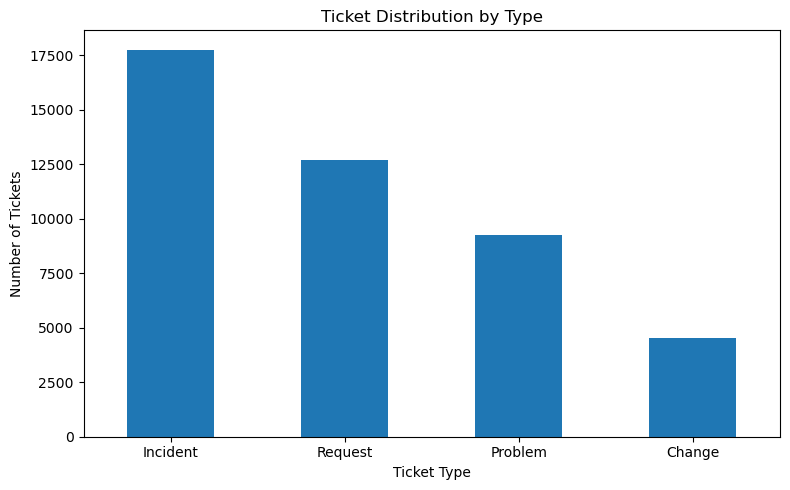

In [16]:
# ========================================================= 13. TICKET TYPE PLOT=========================================================#

if "type" in df.columns:

    df["type"].value_counts().plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Ticket Distribution by Type")
    plt.xlabel("Ticket Type")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [17]:
# ========================================================= 14. LANGUAGE DISTRIBUTION=========================================================#

if "language" in df.columns:

    language_counts = df["language"].value_counts(dropna=False)

    print("Language counts:")
    display(language_counts)

    print("\nLanguage percentages:")
    display(
        (language_counts / len(df) * 100)
        .round(2)
    )

Language counts:


language
en    25138
de    17379
es      812
fr      476
pt      473
Name: count, dtype: int64


Language percentages:


language
en    56.77
de    39.25
es     1.83
fr     1.08
pt     1.07
Name: count, dtype: float64

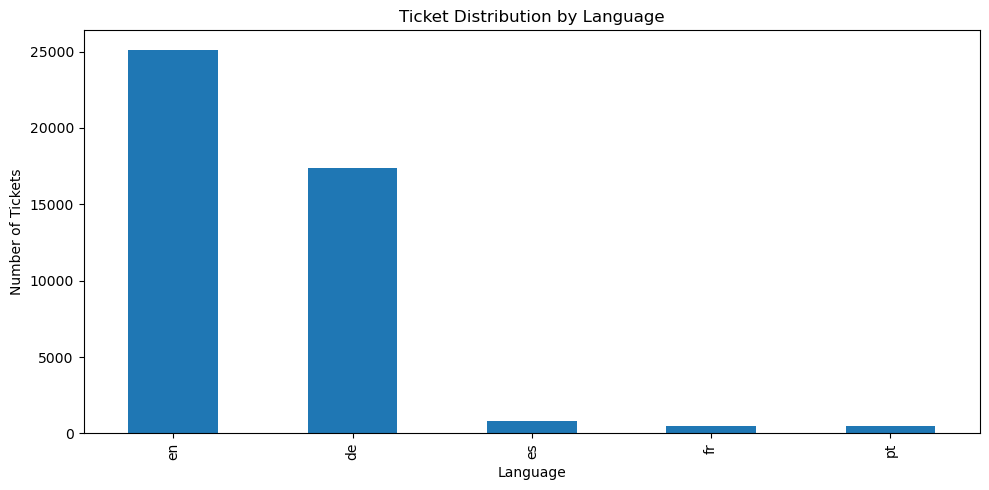

In [18]:
# ========================================================= 15. LANGUAGE DISTRIBUTION PLOT =========================================================#

if "language" in df.columns:

    df["language"].value_counts().plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Ticket Distribution by Language")
    plt.xlabel("Language")
    plt.ylabel("Number of Tickets")

    plt.tight_layout()
    plt.show()

Source dataset counts:


source_dataset
multi-lang-5-2-50-version                     20278
multi-lang-4-20k                              11692
multi-lang-4-20k;multi-lang-5-2-50-version     8308
multi-lang3-4k                                 4000
Name: count, dtype: int64

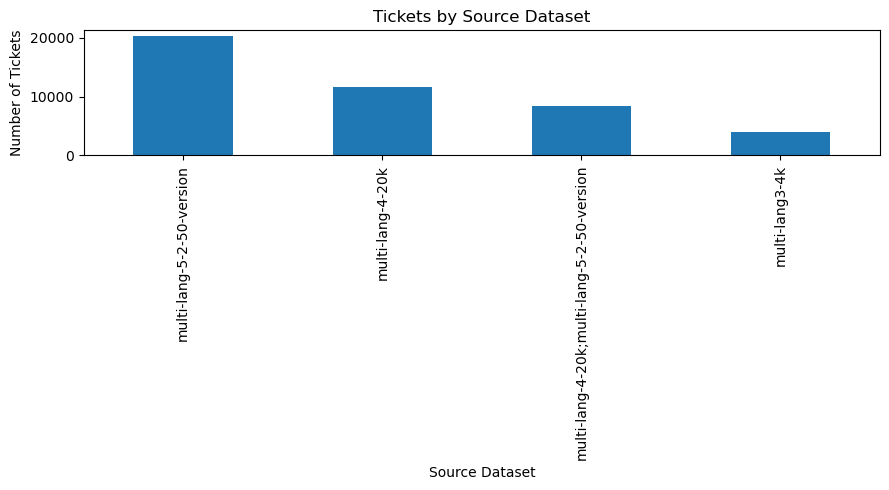

In [19]:
# =========================================================16. SOURCE DATASET DISTRIBUTION=========================================================#

if "source_dataset" in df.columns:

    source_counts = df["source_dataset"].value_counts()

    print("Source dataset counts:")
    display(source_counts)

    source_counts.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title("Tickets by Source Dataset")
    plt.xlabel("Source Dataset")
    plt.ylabel("Number of Tickets")

    plt.tight_layout()
    plt.show()

In [20]:
# =========================================================17. TEXT LENGTH FEATURES=========================================================#

if "ticket_text" in df.columns:

    df["ticket_length_chars"] = (
        df["ticket_text"]
        .fillna("")
        .str.len()
    )

    df["ticket_length_words"] = (
        df["ticket_text"]
        .fillna("")
        .str.split()
        .str.len()
    )

    print("Character length statistics:")
    display(df["ticket_length_chars"].describe())

    print("\nWord length statistics:")
    display(df["ticket_length_words"].describe())

In [21]:
# =========================================================18. TICKET LENGTH HISTOGRAM  =========================================================

if "ticket_length_words" in df.columns:

    plt.figure(figsize=(10, 6))

    df["ticket_length_words"].hist(
        bins=50
    )

    plt.title("Distribution of Ticket Length")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [23]:
# ========================================================= 19 CHARACTER LENGTH HISTOGRAM =========================================================#

if "ticket_length_chars" in df.columns:

    plt.figure(figsize=(10, 6))

    df["ticket_length_chars"].hist(
        bins=50
    )

    plt.title("Distribution of Ticket Character Length")
    plt.xlabel("Characters")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [24]:
# =========================================================QUEUE VS PRIORITY=========================================================#

if (
    "queue" in df.columns
    and "priority" in df.columns
):

    queue_priority = pd.crosstab(
        df["queue"],
        df["priority"]
    )

    display(queue_priority)

priority,high,low,medium
queue,,,
Billing and Payments,1303,933,2132
Customer Service,1270,2214,3257
General Inquiry,79,359,177
Human Resources,87,386,329
IT Support,2519,511,2207
Product Support,2463,1593,4057
Returns and Exchanges,465,823,916
Sales and Pre-Sales,228,501,664
Service Outages and Maintenance,1223,187,300


In [26]:
# ========================================================= 27. QUEUE VS TYPE =========================================================#

if (
    "queue" in df.columns
    and "type" in df.columns
):

    queue_type = pd.crosstab(
        df["queue"],
        df["type"]
    )

    display(queue_type)

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,253,1052,949,2114
Customer Service,487,1731,1390,3133
General Inquiry,173,197,98,147
Human Resources,57,413,88,244
IT Support,885,1902,1364,1086
Product Support,940,3506,1806,1861
Returns and Exchanges,280,845,453,626
Sales and Pre-Sales,245,305,184,659
Service Outages and Maintenance,419,936,103,252


In [27]:
# =========================================================28. CLASS IMBALANCE ANALYSIS=========================================================#

if "queue" in df.columns:

    queue_counts = df["queue"].value_counts()

    largest_class = queue_counts.max()
    smallest_class = queue_counts.min()

    imbalance_ratio = largest_class / smallest_class

    print("Largest class:", largest_class)
    print("Smallest class:", smallest_class)
    print(
        "Largest-to-smallest class ratio:",
        round(imbalance_ratio, 2)
    )

Largest class: 13095
Smallest class: 615
Largest-to-smallest class ratio: 21.29


In [28]:
# =========================================================29. CLASS IMBALANCE SUMMARY TABLE========================================================#

if "queue" in df.columns:

    queue_summary = pd.DataFrame({
        "count": df["queue"].value_counts()
    })

    queue_summary["percentage"] = (
        queue_summary["count"]
        / len(df)
        * 100
    ).round(2)

    display(queue_summary)

,count,percentage
queue,,
Technical Support,13095,29.57
Product Support,8113,18.32
Customer Service,6741,15.22
IT Support,5237,11.83
Billing and Payments,4368,9.86
Returns and Exchanges,2204,4.98
Service Outages and Maintenance,1710,3.86
Sales and Pre-Sales,1393,3.15
Human Resources,802,1.81


In [29]:
# =========================================================30. RANDOM SAMPLE INSPECTION=========================================================#

sample_columns = [
    col for col in
    [
        "subject",
        "body",
        "ticket_text",
        "queue",
        "priority",
        "type",
        "language",
        "source_dataset"
    ]
    if col in df.columns
]

display(
    df[sample_columns]
    .sample(10, random_state=42)
)

,subject,body,queue,priority,type,language,source_dataset
36251,Request for Data Lockdown,Data lockdown was detected; sensitive medical information might have been exposed due to outdated security protocols. Anti-virus software has been...,Technical Support,high,Problem,de,multi-lang-5-2-50-version
43037,Request for Mesh Network Support,"We are facing intermittent connectivity problems with the Netgear Nighthawk Mesh system, which is affecting our data analysis tools and efforts to...",Technical Support,medium,Incident,en,multi-lang-5-2-50-version
31069,Unexpected System Failure,"The data analytics platform is crashing suddenly, potentially due to software conflicts. I have rebooted the systems and verified updates, but the...",Technical Support,high,Incident,en,multi-lang-5-2-50-version
33778,Eiliger IT-Support erforderlich,"Das IT-System des Krankenhauses wurde unautorisiert zugänglich gemacht, wodurch sensible medizinische Daten möglicherweise kompromittiert wurden. ...",Technical Support,low,Incident,de,multi-lang-5-2-50-version
25044,Cassandra-Integration,"Bitte nehmen Sie Kontakt auf, um eine Beratung zur Integration von Cassandra 4.0 in RapidMiner zu erhalten. Wir suchen nach verbesserten Methoden ...",Technical Support,low,Request,de,multi-lang-5-2-50-version
23662,Securing Medical Data in Hospital Settings,Please provide detailed solutions.,Sales and Pre-Sales,medium,Request,en,multi-lang-4-20k
6075,Encountered Issues with Medical Data Encryption,There has been a failure in the encryption of medical data. There may be an issue with the configuration of the Scikit-learn library. Steps alread...,Technical Support,low,Incident,en,multi-lang-4-20k
2541,NaN,"Dear IT Services Support Team,<br><br>We are experiencing an issue with Jira Software 8.20. Our clients are unable to create user accounts, and th...",Technical Support,high,Incident,en,multi-lang3-4k
10458,Report Generation Issue,The data analytics tool has ceased to generate reports due to a software update.,Technical Support,medium,Incident,en,multi-lang-4-20k;multi-lang-5-2-50-version
18618,Optimizing Marketing with Ableton Live,I am seeking advice on using Ableton Live for digital marketing strategies. Could you provide insights on how to effectively utilize the tool? Spe...,IT Support,high,Request,en,multi-lang-4-20k;multi-lang-5-2-50-version


In [30]:
# =========================================================31. SAMPLE TICKETS BY QUEUE# =========================================================


if "queue" in df.columns:

    for queue_name in df["queue"].dropna().unique():

        print("\n" + "=" * 80)
        print("QUEUE:", queue_name)
        print("=" * 80)

        sample = (
            df[df["queue"] == queue_name]
            .sample(
                min(3, len(df[df["queue"] == queue_name])),
                random_state=42
            )
        )

        display(
            sample[
                [
                    col for col in
                    [
                        "ticket_text",
                        "priority",
                        "language"
                    ]
                    if col in sample.columns
                ]
            ]
        )


QUEUE: Technical Support


,priority,language
4591,high,en
13396,medium,en
25217,high,de



QUEUE: Customer Service


,priority,language
1363,high,pt
21293,medium,de
16801,medium,de



QUEUE: IT Support


...

,priority,language
16023,medium,de
12260,medium,en
35735,high,en



QUEUE: Sales and Pre-Sales


,priority,language
9863,low,de
34752,low,en
31231,low,de



QUEUE: Human Resources


,priority,language
11621,medium,de
17490,low,en
10104,medium,en


In [31]:
# ========================================================= 31. SAMPLE TICKETS BY QUEUE=========================================================#

if "queue" in df.columns:

    for queue_name in df["queue"].dropna().unique():

        print("\n" + "=" * 80)
        print("QUEUE:", queue_name)
        print("=" * 80)

        sample = (
            df[df["queue"] == queue_name]
            .sample(
                min(3, len(df[df["queue"] == queue_name])),
                random_state=42
            )
        )

        display(
            sample[
                [
                    col for col in
                    [
                        "ticket_text",
                        "priority",
                        "language"
                    ]
                    if col in sample.columns
                ]
            ]
        )


QUEUE: Technical Support


,priority,language
4591,high,en
13396,medium,en
25217,high,de



QUEUE: Customer Service


,priority,language
1363,high,pt
21293,medium,de
16801,medium,de



QUEUE: IT Support


...

,priority,language
16023,medium,de
12260,medium,en
35735,high,en



QUEUE: Sales and Pre-Sales


,priority,language
9863,low,de
34752,low,en
31231,low,de



QUEUE: Human Resources


,priority,language
11621,medium,de
17490,low,en
10104,medium,en


In [32]:
# ========================================================= 32. CHECK MISSING TARGET LABELS=========================================================

TARGET = "queue"

if TARGET in df.columns:

    missing_target = df[TARGET].isnull().sum()

    print(
        f"Missing {TARGET} labels:",
        missing_target
    )

Missing queue labels: 0


In [33]:
# ========================================================= 33. CHECK EMPTY TARGET LABELS=========================================================

if TARGET in df.columns:

    empty_target = (
        df[TARGET]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(
        f"Empty {TARGET} labels:",
        empty_target
    )

Empty queue labels: 0


In [34]:
# ========================================================= 34. CHECK EMPTY TEXT =========================================================

if "ticket_text" in df.columns:

    empty_text = (
        df["ticket_text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(
        "Empty ticket_text rows:",
        empty_text
    )

In [35]:
# =========================================================
# 35. POTENTIAL DATA LEAKAGE CHECK
# =========================================================

# Search for obvious target words inside the ticket text.
# This does not prove leakage, but it is useful for inspection.

if (
    "queue" in df.columns
    and "ticket_text" in df.columns
):

    leakage_results = []

    for queue_name in df["queue"].dropna().unique():

        queue_string = str(queue_name).lower()

        count = (
            df["ticket_text"]
            .fillna("")
            .str.lower()
            .str.contains(
                queue_string,
                regex=False
            )
            .sum()
        )

        leakage_results.append({
            "queue": queue_name,
            "tickets_containing_queue_name": count
        })

    leakage_df = pd.DataFrame(leakage_results)

    display(
        leakage_df.sort_values(
            "tickets_containing_queue_name",
            ascending=False
        )
    )

In [24]:
# =========================================================
# 36. SOURCE DUPLICATION ANALYSIS
# =========================================================

if "source_count" in df.columns:

    print("Source count distribution:")

    display(
        df["source_count"]
        .value_counts()
        .sort_index()
    )

Source count distribution:


source_count
1    35970
2     8308
Name: count, dtype: int64

In [36]:
# ========================================================= 37. ORIGINAL DUPLICATE RECORD COUNTS =========================================================

if "duplicate_record_count" in df.columns:

    display(
        df["duplicate_record_count"]
        .value_counts()
        .sort_index()
    )

    print(
        "Tickets that originally appeared more than once:",
        (df["duplicate_record_count"] > 1).sum()
    )

duplicate_record_count
1    35970
2     8307
3        1
Name: count, dtype: int64

Tickets that originally appeared more than once: 8308


In [37]:
# ========================================================= 38. TOP ORIGINAL DUPLICATES =========================================================

if (
    "duplicate_record_count" in df.columns
    and "ticket_text" in df.columns
):

    top_duplicates = (
        df.sort_values(
            "duplicate_record_count",
            ascending=False
        )
        [
            [
                col for col in
                [
                    "ticket_text",
                    "duplicate_record_count",
                    "source_count",
                    "queue"
                ]
                if col in df.columns
            ]
        ]
        .head(20)
    )

    display(top_duplicates)

In [38]:
# ========================================================= 39. MODEL-READINESS SUMMARY =========================================================

print("=" * 70)
print("MODEL READINESS SUMMARY")
print("=" * 70)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

if "queue" in df.columns:
    print(
        f"Unique routing queues: "
        f"{df['queue'].nunique()}"
    )

if "language" in df.columns:
    print(
        f"Unique languages: "
        f"{df['language'].nunique()}"
    )

if "priority" in df.columns:
    print(
        f"Unique priorities: "
        f"{df['priority'].nunique()}"
    )

if "type" in df.columns:
    print(
        f"Unique ticket types: "
        f"{df['type'].nunique()}"
    )

if "ticket_text" in df.columns:

    print(
        f"Median ticket length: "
        f"{df['ticket_length_words'].median():.0f} words"
    )

    print(
        f"Mean ticket length: "
        f"{df['ticket_length_words'].mean():.2f} words"
    )

    print(
        f"Maximum ticket length: "
        f"{df['ticket_length_words'].max():,.0f} words"
    )

print("\nExact duplicates:", df.duplicated().sum())

MODEL READINESS SUMMARY

Total rows: 44,278
Total columns: 21
Unique routing queues: 10
Unique languages: 5
Unique priorities: 3
Unique ticket types: 4

Exact duplicates: 0
